## Imports


In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score,roc_auc_score,roc_curve
import warnings
warnings.filterwarnings('ignore')



In [39]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\workstation\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

## load the dataset

In [4]:
df = pd.read_csv('fake_news.csv')
df.head()

,id,title,author,text,label
0,0,House Dem Aide: We Didn’t Even See Comey’s Let...,Darrell Lucus,House Dem Aide: We Didn’t Even See Comey’s Let...,1
1,1,"FLYNN: Hillary Clinton, Big Woman on Campus - ...",Daniel J. Flynn,Ever get the feeling your life circles the rou...,0
2,2,Why the Truth Might Get You Fired,Consortiumnews.com,"Why the Truth Might Get You Fired October 29, ...",1
3,3,15 Civilians Killed In Single US Airstrike Hav...,Jessica Purkiss,Videos 15 Civilians Killed In Single US Airstr...,1
4,4,Iranian woman jailed for fictional unpublished...,Howard Portnoy,Print \nAn Iranian woman has been sentenced to...,1


In [7]:
df.loc[0,"text"]

'House Dem Aide: We Didn’t Even See Comey’s Letter Until Jason Chaffetz Tweeted It By Darrell Lucus on October 30, 2016 Subscribe Jason Chaffetz on the stump in American Fork, Utah ( image courtesy Michael Jolley, available under a Creative Commons-BY license) \nWith apologies to Keith Olbermann, there is no doubt who the Worst Person in The World is this week–FBI Director James Comey. But according to a House Democratic aide, it looks like we also know who the second-worst person is as well. It turns out that when Comey sent his now-infamous letter announcing that the FBI was looking into emails that may be related to Hillary Clinton’s email server, the ranking Democrats on the relevant committees didn’t hear about it from Comey. They found out via a tweet from one of the Republican committee chairmen. \nAs we now know, Comey notified the Republican chairmen and Democratic ranking members of the House Intelligence, Judiciary, and Oversight committees that his agency was reviewing emai

## Check for missing values

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20800 entries, 0 to 20799
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      20800 non-null  int64
 1   title   20242 non-null  str  
 2   author  18843 non-null  str  
 3   text    20761 non-null  str  
 4   label   20800 non-null  int64
dtypes: int64(2), str(3)
memory usage: 94.6 MB


In [9]:
df.isna().sum()

id           0
title      558
author    1957
text        39
label        0
dtype: int64

# Data Preprocessing

## handling null values

In [10]:
df.fillna("",inplace=True)

,id,title,author,text,label
0,0,House Dem Aide: We Didn’t Even See Comey’s Let...,Darrell Lucus,House Dem Aide: We Didn’t Even See Comey’s Let...,1
1,1,"FLYNN: Hillary Clinton, Big Woman on Campus - ...",Daniel J. Flynn,Ever get the feeling your life circles the rou...,0
2,2,Why the Truth Might Get You Fired,Consortiumnews.com,"Why the Truth Might Get You Fired October 29, ...",1
3,3,15 Civilians Killed In Single US Airstrike Hav...,Jessica Purkiss,Videos 15 Civilians Killed In Single US Airstr...,1
4,4,Iranian woman jailed for fictional unpublished...,Howard Portnoy,Print \nAn Iranian woman has been sentenced to...,1
...,...,...,...,...,...
20795,20795,Rapper T.I.: Trump a ’Poster Child For White S...,Jerome Hudson,Rapper T. I. unloaded on black celebrities who...,0
20796,20796,"N.F.L. Playoffs: Schedule, Matchups and Odds -...",Benjamin Hoffman,When the Green Bay Packers lost to the Washing...,0
20797,20797,Macy’s Is Said to Receive Takeover Approach by...,Michael J. de la Merced and Rachel Abrams,The Macy’s of today grew from the union of sev...,0
20798,20798,"NATO, Russia To Hold Parallel Exercises In Bal...",Alex Ansary,"NATO, Russia To Hold Parallel Exercises In Bal...",1


## create a new column containing the combination of the title and author columns

In [11]:
df['content']=df['title']+" "+df['author']

In [13]:
df.head()

,id,title,author,text,label,content
0,0,House Dem Aide: We Didn’t Even See Comey’s Let...,Darrell Lucus,House Dem Aide: We Didn’t Even See Comey’s Let...,1,House Dem Aide: We Didn’t Even See Comey’s Let...
1,1,"FLYNN: Hillary Clinton, Big Woman on Campus - ...",Daniel J. Flynn,Ever get the feeling your life circles the rou...,0,"FLYNN: Hillary Clinton, Big Woman on Campus - ..."
2,2,Why the Truth Might Get You Fired,Consortiumnews.com,"Why the Truth Might Get You Fired October 29, ...",1,Why the Truth Might Get You Fired Consortiumne...
3,3,15 Civilians Killed In Single US Airstrike Hav...,Jessica Purkiss,Videos 15 Civilians Killed In Single US Airstr...,1,15 Civilians Killed In Single US Airstrike Hav...
4,4,Iranian woman jailed for fictional unpublished...,Howard Portnoy,Print \nAn Iranian woman has been sentenced to...,1,Iranian woman jailed for fictional unpublished...


## check the balance of the dataset

In [ ]:
df['label'].value_counts()

label
1    10413
0    10387
Name: count, dtype: int64

## EDA

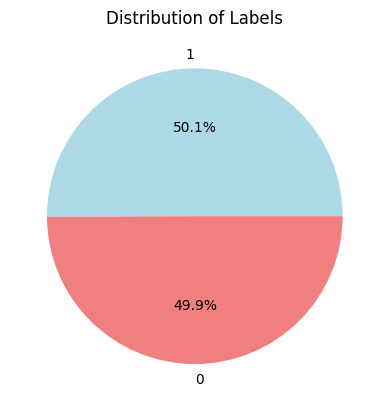

In [20]:
df['label'].value_counts().plot(kind='pie', autopct='%1.1f%%',colors=['lightblue', 'lightcoral'])
plt.ylabel('')
plt.title('Distribution of Labels')
plt.show()

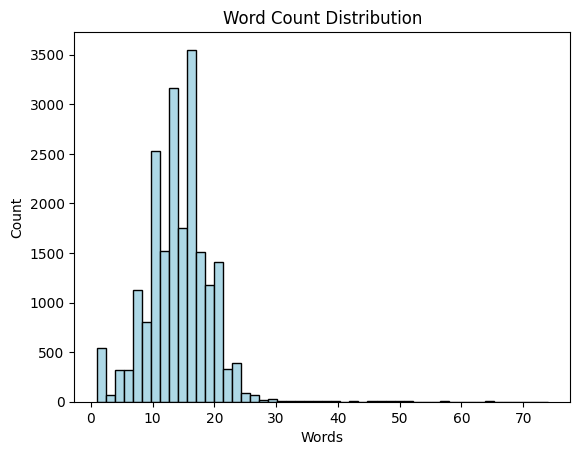

In [22]:
df['word_count'] = df['content'].apply(lambda x: len(x.split()))

plt.hist(df['word_count'], bins=50,color='lightblue', edgecolor='black')

plt.title('Word Count Distribution')
plt.xlabel('Words')
plt.ylabel('Count')
plt.show()

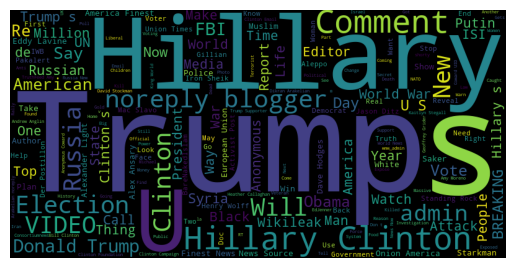

In [ ]:
from wordcloud import WordCloud

fake_text = " ".join(df[df['label']==1]['content'])

wc = WordCloud(width=800, height=400).generate(fake_text)

plt.imshow(wc)
plt.axis('off')
plt.show()

## Stemming Function

### # Text Preprocessing (Stemming Function) Summary

In this code, we prepared the text data for a Fake News detection model using preprocessing steps.

First, we created a set of stopwords using NLTK, which are common words like (the, is, and) that do not carry much meaning for classification, so we remove them.

Then inside the `stemming` function, we start by cleaning the text using regex to remove all non-alphabetic characters (numbers and symbols), keeping only letters.

After that, we convert all text to lowercase to make the format consistent (e.g., AI = ai).

Next, we split the text into individual words (tokenization).

Then we remove stopwords and apply stemming to each word, which reduces words to their root form (e.g., playing → play).

Finally, we join the processed words back into a single string using `" ".join()`.

The final output is clean, normalized text that is ready to be used for Machine Learning model training.

In [41]:
    stop_words = set(stopwords.words('english'))
    port_stem = PorterStemmer()

    def stemming(content):
        stemmed_content = re.sub('[^a-zA-Z]', ' ', content)
        stemmed_content = stemmed_content.lower()
        stemmed_content = stemmed_content.split()

        stemmed_content = [
            port_stem.stem(word)
            for word in stemmed_content
            if word not in stop_words
        ]

        stemmed_content = " ".join(stemmed_content)
        return stemmed_content

In [43]:
df['content']=df['content'].apply(stemming)

In [44]:
df['content']

0        hou dem aid even see comey letter jason chaffe...
1        flynn hillari clinton big woman campu breitbar...
2                   truth might get fire consortiumnew com
3        civilian kill singl us airstrik identifi jessi...
4        iranian woman jail fiction unpublish stori wom...
                               ...                        
20795    rapper trump poster child white supremaci jero...
20796    n f l playoff schedul matchup odd new york tim...
20797    maci said receiv takeov approach hudson bay ne...
20798    nato russia hold parallel exerci balkan alex a...
20799                            keep f aliv david swanson
Name: content, Length: 20800, dtype: str

## Converting the textual data to numerical data

In [49]:
tfidf = TfidfVectorizer(ngram_range=(1,2))
X = tfidf.fit_transform(df['content'].values)

In [55]:
print(X.shape)

(20800, 131269)


## show the feature names

In [51]:
print(tfidf.get_feature_names_out())

['aa' 'aa ball' 'aaa' ... 'zwo drei' 'zwyghuizen' 'zzz']


## split data into train and test split

In [54]:
y = df['label'].values

In [56]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


##  Shape of train and test

In [57]:
print(x_train.shape)
print(x_test.shape)

(16640, 131269)
(4160, 131269)


# Model evaluation

## LogisticRegression

In [71]:
lr_model =LogisticRegression()
lr_model.fit(x_train,y_train)
y_pred=lr_model.predict(x_test)


In [73]:
print(f"Training Accuracy: {lr_model.score(x_train, y_train)}")
print(f"Testing Accuracy: {lr_model.score(x_test, y_test)}")

Training Accuracy: 0.9867788461538461
Testing Accuracy: 0.9675480769230769


In [74]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.94      0.97      2132
           1       0.94      0.99      0.97      2028

    accuracy                           0.97      4160
   macro avg       0.97      0.97      0.97      4160
weighted avg       0.97      0.97      0.97      4160



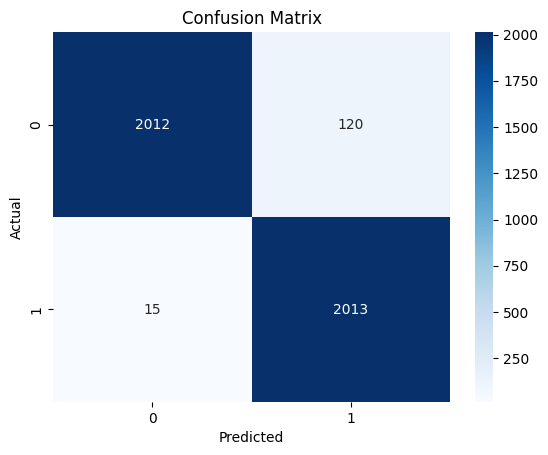

In [76]:
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## SVC 

In [77]:
svm_model = SVC()
svm_model.fit(x_train, y_train)
y_pred_svm = svm_model.predict(x_test)
print(f"SVM Training Accuracy: {svm_model.score(x_train, y_train)}")
print(f"SVM Testing Accuracy: {svm_model.score(x_test, y_test)}")

SVM Training Accuracy: 0.9997596153846153
SVM Testing Accuracy: 0.9822115384615384


In [78]:
print(classification_report(y_test,y_pred_svm))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      2132
           1       0.97      0.99      0.98      2028

    accuracy                           0.98      4160
   macro avg       0.98      0.98      0.98      4160
weighted avg       0.98      0.98      0.98      4160



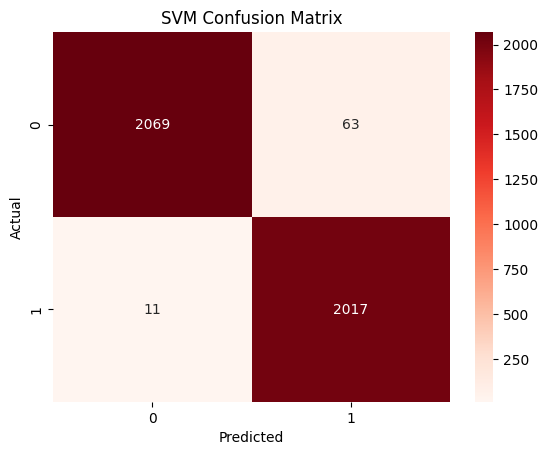

In [79]:
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(conf_matrix_svm, annot=True, fmt='d', cmap='Reds')
plt.xlabel('Predicted') 
plt.ylabel('Actual')
plt.title('SVM Confusion Matrix')
plt.show()

## Decision Tree Classifier

In [81]:
dt_model_param = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [5, 10, 50, None],
    'class_weight': [None, 'balanced']
}
dt_model = DecisionTreeClassifier()
grid_search_dt = GridSearchCV(estimator=dt_model, param_grid=dt_model_param, cv=5, n_jobs=-1, verbose=2)
grid_search_dt.fit(x_train, y_train)
print(f"Best Parameters for Decision Tree: {grid_search_dt.best_params_}")


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters for Decision Tree: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None}


In [82]:
best_dt_model = grid_search_dt.best_estimator_
y_pred_dt = best_dt_model.predict(x_test)
print(f"Decision Tree Training Accuracy: {best_dt_model.score(x_train, y_train)}")
print(f"Decision Tree Testing Accuracy: {best_dt_model.score(x_test, y_test)}")

Decision Tree Training Accuracy: 1.0
Decision Tree Testing Accuracy: 0.9944711538461538


In [83]:
print(classification_report(y_test,y_pred_dt))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      2132
           1       0.99      1.00      0.99      2028

    accuracy                           0.99      4160
   macro avg       0.99      0.99      0.99      4160
weighted avg       0.99      0.99      0.99      4160



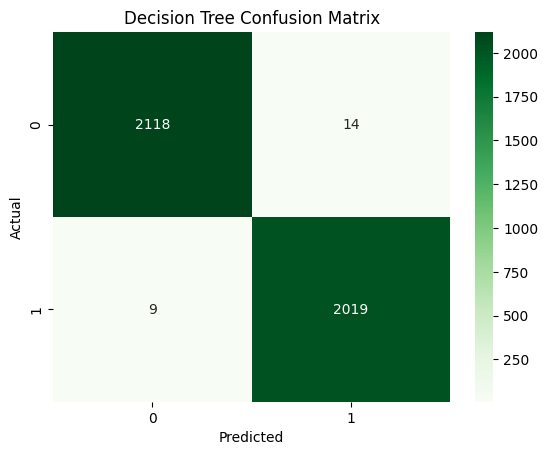

In [84]:
conf_matrix_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(conf_matrix_dt, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree Confusion Matrix')
plt.show()

## RandomForestClassifier

In [90]:
rf_model = RandomForestClassifier()
rf_param = {
    'n_estimators': [100, 200],
    'max_depth': [10, 50, None],
}
grid_search_rf = GridSearchCV(estimator=rf_model,param_grid=rf_param, cv=5)
grid_search_rf.fit(x_train, y_train)
print(f"Best Parameters for Random Forest: {grid_search_rf.best_params_}")

Best Parameters for Random Forest: {'max_depth': None, 'n_estimators': 200}


In [96]:
best_rf_model = grid_search_rf.best_estimator_
y_pred_rf = best_rf_model.predict(x_test)
print(f"Random Forest Training Accuracy: {best_rf_model.score(x_train, y_train)}")
print(f"Random Forest Testing Accuracy: {best_rf_model.score(x_test, y_test)}")


Random Forest Training Accuracy: 1.0
Random Forest Testing Accuracy: 0.9923076923076923


In [97]:
print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      2132
           1       0.99      1.00      0.99      2028

    accuracy                           0.99      4160
   macro avg       0.99      0.99      0.99      4160
weighted avg       0.99      0.99      0.99      4160



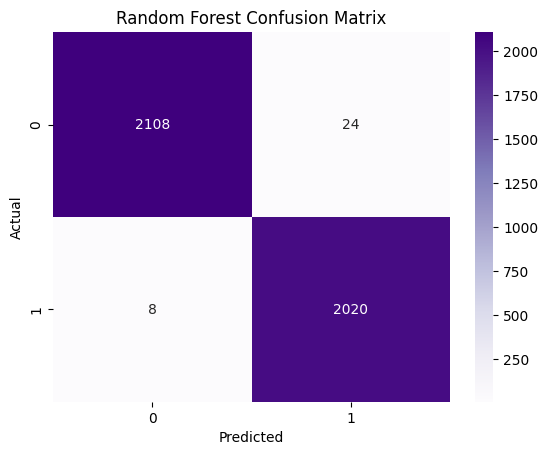

In [98]:
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Purples')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()

## Comparing performance of all trained models

In [99]:
comparison=pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM', 'Decision Tree', 'Random Forest'],
    'Training Accuracy': [model.score(x_train, y_train), svm_model.score(x_train, y_train), best_dt_model.score(x_train, y_train), best_rf_model.score(x_train, y_train)],
    'Testing Accuracy': [model.score(x_test, y_test), svm_model.score(x_test, y_test), best_dt_model.score(x_test, y_test), best_rf_model.score(x_test, y_test)]
})
print(comparison)



                 Model  Training Accuracy  Testing Accuracy
0  Logistic Regression           0.986779          0.967548
1                  SVM           0.999760          0.982212
2        Decision Tree           1.000000          0.994471
3        Random Forest           1.000000          0.992308


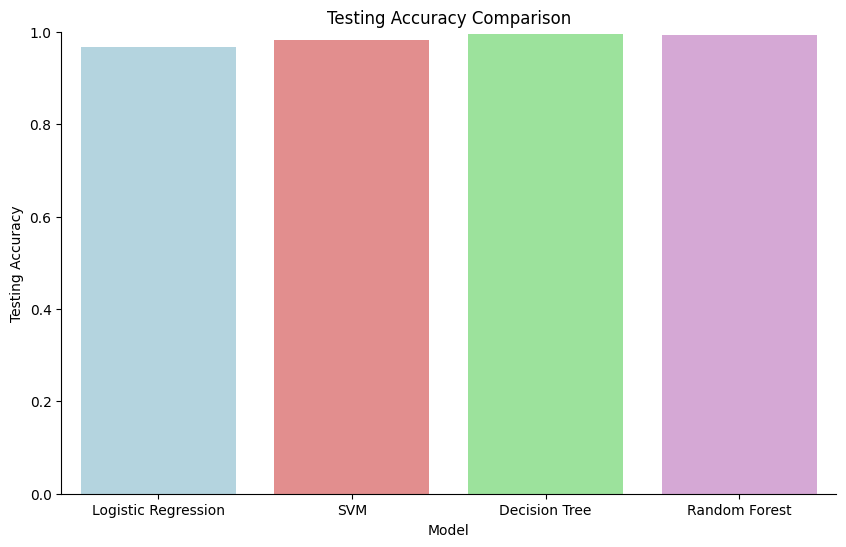

In [103]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Model',
    y='Testing Accuracy',
    data=comparison,
    palette=['lightblue', 'lightcoral', 'lightgreen', 'plum']
)

sns.despine()

plt.ylim(0, 1)
plt.title('Testing Accuracy Comparison')
plt.ylabel('Testing Accuracy')
plt.xlabel('Model')

plt.show()

## save the best model

In [104]:
import pickle
with open('fake_news_model.pkl', 'wb') as file:
    pickle.dump(best_dt_model, file)